In [1]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn

import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones
import torch
from numpy import pi, exp, conj, min, argmin, unravel_index, log
import warnings
warnings.filterwarnings("ignore")

In [2]:
def hl2(n, x):
    return spherical_jn(n, x) - 1j * spherical_yn(n, x)

def hl2prime(n, x):
    hn = hl2(n, x)
    hn1 = hl2(n+1, x)
    return n/x * hn - hn1

def hl1(n, x):
    return spherical_jn(n, x) + 1j * spherical_yn(n, x)

def hl1prime(n, x):
    hn = hl1(n, x)
    hn1 = hl1(n+1, x)
    return n/x * hn - hn1

In [119]:
M = 1000
epsilon = 1
x = linspace(1500, 1510, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [120]:
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [121]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)

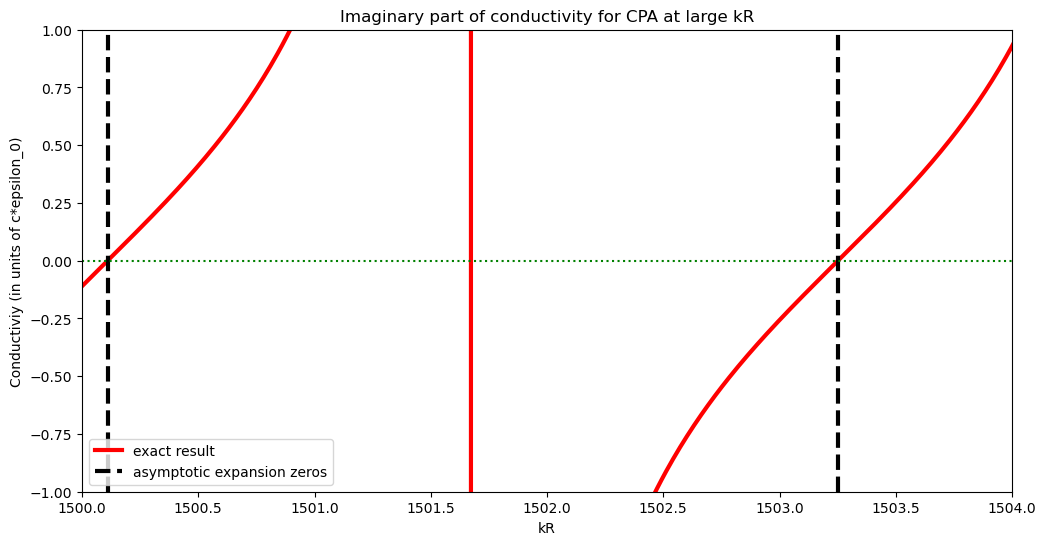

In [123]:
x_1 = 1500
x_2 = 1504
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x, sigmas[1, :], color="red", linewidth=3, label="exact result")
#ax.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansion")
ax.set_ylim(-1, 1)
ax.vlines([pi/2/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax.set_xlim(x_1, x_2);
ax.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax.set_xlabel("kR")
ax.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax.set_title("Imaginary part of conductivity for CPA at large kR");
ax.legend();

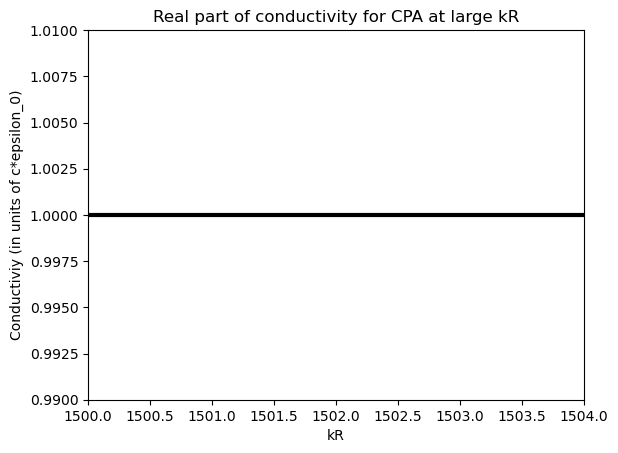

In [126]:
plt.plot(x, sigmas[0, :], color="black", linewidth=3)
#plt.plot(x, sigmas_asymptotic.real, color="red", linewidth=3)

#plt.vlines([-pi/4/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3)
plt.xlim(x_1, x_2);
plt.ylim(0.99, 1.01)
plt.xlabel("kR")
plt.ylabel("Conductiviy (in units of c*epsilon_0)");
plt.title("Real part of conductivity for CPA at large kR");

In [325]:
M = 1000
epsilon = 1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [326]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)

In [327]:
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]

In [328]:
sigma_omegas[:, np.argmin(np.abs(x-0.01))][1]/0.01

1.5001050000632876

In [329]:
quasistatic_dispersion = x*(l*epsilon+(l+1))/(l*(l+1))

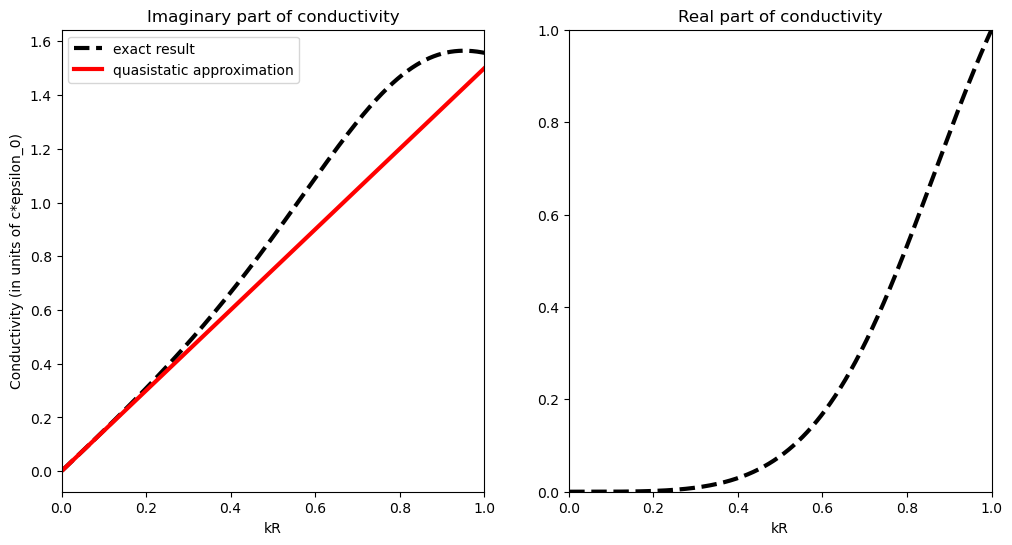

In [330]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.plot(x, quasistatic_dispersion, label="quasistatic approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.set_xlim(0, 1)
#ax1.set_ylim(0, 2)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");


In [8]:
hbar = 6.67*1e-16 # hbar in eV*seconds
tau = 6.4*1e-13 # scattering time in seconds
c = 3*10**17; # speed of light in nanometers per second
alpha = 1/137; # fine structure constant

In [332]:
E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha;
a = c*tau*x*sigma_real/sigma_imaginary;

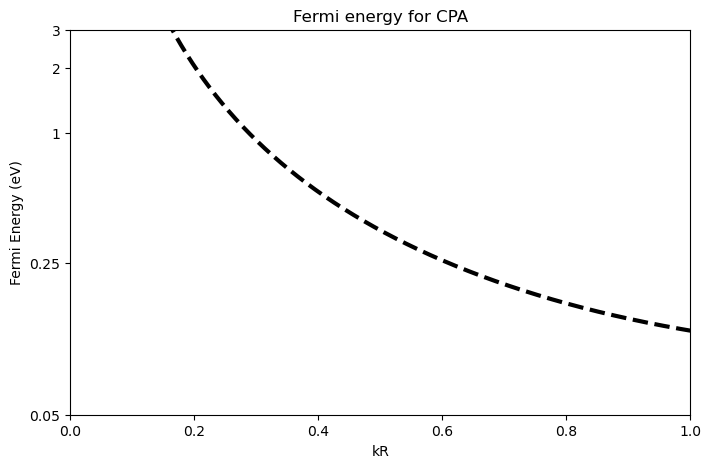

In [333]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, log(E_F), color="black", linestyle="dashed", linewidth=3)
ax.set_yticks([log(0.05), log(0.25), log(1), log(2), log(3)], [0.05, 0.25, 1, 2, 3])
ax.set_ylim(log(0.05), log(3));
ax.set_xlim(0, 1)
ax.set_xlabel("kR");
ax.set_ylabel("Fermi Energy (eV)");
ax.set_title("Fermi energy for CPA");

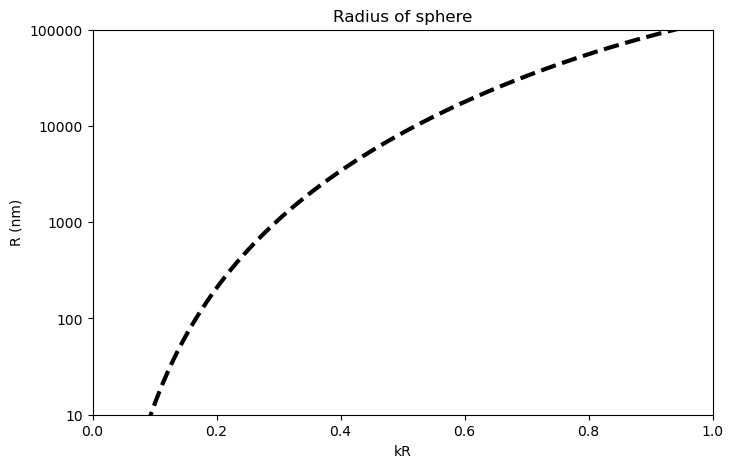

In [334]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, log(a), color="black", linestyle="dashed", linewidth=3)
ax.set_yticks([log(1e1), log(1e2), log(1e3), log(1e4), log(1e5)], [10, 100, 1000, 10000, 100000])
ax.set_ylim(log(1e1), log(1e5));
ax.set_xlim(0, 1)
ax.set_xlabel("kR");
ax.set_ylabel("R (nm)");
ax.set_title("Radius of sphere");

### Now we calculate the bandwidth for CPA

In [335]:
idx = 800
omega = c*x[idx]/a[idx]
sigma = 4*1j*alpha*E_F[idx]/(hbar*(omega+1j/tau))

In [336]:
omega_range = linspace(1, 7, 1000)*1e12 # frequency in Hertz 
sigma_range = 4*1j*alpha*E_F[idx]/(hbar*(omega_range+1j/tau)) # Graphene conductivity over the frequency range
g_omega_range = sigma_range*1j/x[idx] 

In [337]:
x_range = omega_range * a[idx]/c
l = 1
real_epsilon = 1
epsilon = real_epsilon 
y_range = x_range * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x_range) + x_range * hl2prime(l, x_range)
xhl1_prime = hl1(l, x_range) + x_range * hl1prime(l, x_range)
yjl_prime = spherical_jn(l, y_range) + y_range*spherical_jn(l, y_range, derivative=True)

numerator = epsilon * spherical_jn(l, y_range) * xhl2_prime - yjl_prime * hl2(l, x_range) + (g_omega_range) * xhl2_prime * yjl_prime
denominator = -epsilon * spherical_jn(l, y_range) * xhl1_prime + yjl_prime * hl1(l, x_range) - (g_omega_range) * xhl1_prime * yjl_prime

In [338]:
print("Minimum |s|^2: ", min(abs(numerator/denominator)**2))
idxs = unravel_index(argmin(abs(numerator/denominator)**2), numerator.shape)

Minimum |s|^2:  6.449841277646023e-07


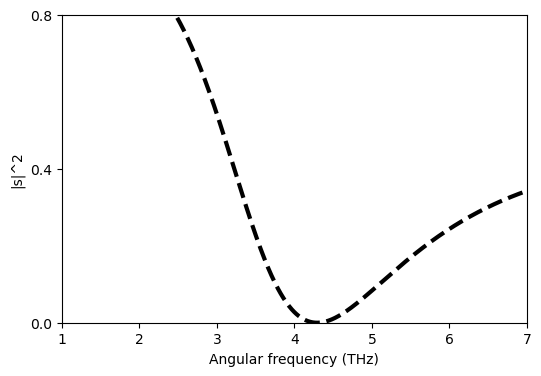

In [339]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(omega_range/1e12, abs(numerator/denominator)**2, color="black", linestyle="dashed", linewidth=3)
ax.set_ylim(0, 0.8)
ax.set_yticks([0, 0.4, 0.8])
ax.set_xlim(1, 7);
ax.set_xlabel("Angular frequency (THz)");
ax.set_ylabel("|s|^2");

### TE modes

In [3]:
M = 1000
epsilon = 1
x_1 = 1e-3
x_2 = 0.09
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = (1/x)/(j_ly*(j_lx**2+y_lx**2))
mat = np.array([[y_lx, j_lx], [-j_lx , y_lx]])
vec = np.array([j_lx*yjl_prime-xjl_prime*j_ly, j_ly*xyl_prime-y_lx*yjl_prime])

In [4]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)

In [5]:
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]

In [6]:
small_sphere_dispersion = -(2*l+1)/x

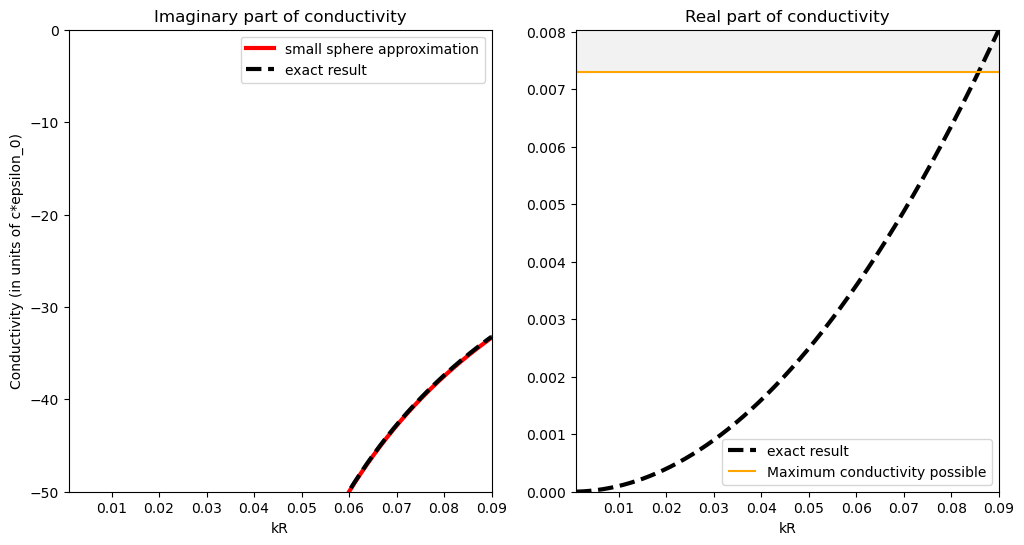

In [128]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, small_sphere_dispersion, label="small sphere approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(x_1, x_2)
ax1.set_ylim(-50, 0)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.hlines([alpha], x_1, x_2, label="Maximum conductivity possible", color="orange")
ax2.fill([x_1, x_1, x_2, x_2], [alpha, 2*alpha, 2*alpha, alpha], color="grey", alpha=0.1)
ax2.set_ylim(sigma_real.min(), sigma_real.max())
ax2.set_ylim(0, )
ax2.set_xlim(x_1, x_2)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");
ax2.legend();

In [52]:
E_F_1 = (hbar/tau)*(alpha+sqrt(alpha**2-sigma_real**2))/(2*sigma_real);
E_F_2 = (hbar/tau)*(alpha-sqrt(alpha**2-sigma_real**2))/(2*sigma_real);

a_1 = c*x*hbar/(2*E_F_1);
a_2 = c*x*hbar/(2*E_F_2);

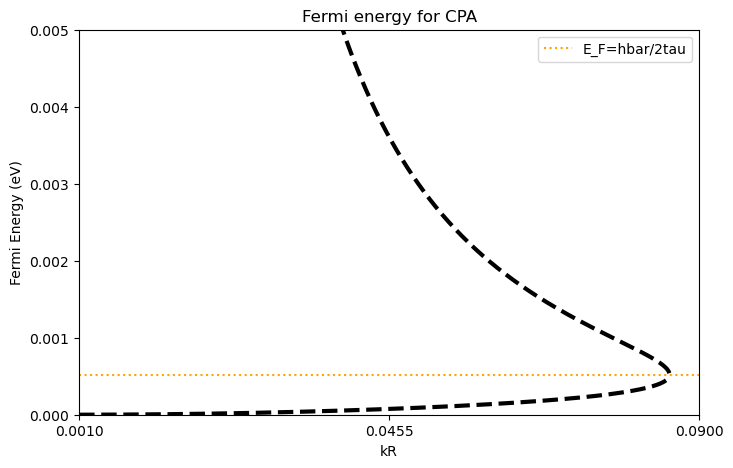

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, E_F_1, color="black", linestyle="dashed", linewidth=3)
ax.plot(x, E_F_2, color="black", linestyle="dashed", linewidth=3)

ax.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax.set_xlim(x_1, x_2)
ax.set_ylim(0, 0.005)
ax.set_xlabel("kR");
ax.set_ylabel("Fermi Energy (eV)");
ax.hlines([hbar/(2*tau)], x_1, x_2, linestyle="dotted", color="orange", label="E_F=hbar/2tau")
ax.legend()
ax.set_title("Fermi energy for CPA");

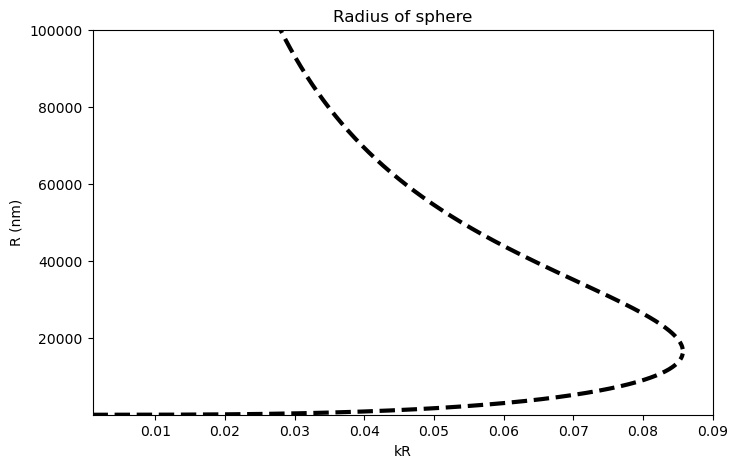

In [54]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, a_1, color="black", linestyle="dashed", linewidth=3)
ax.plot(x, a_2, color="black", linestyle="dashed", linewidth=3)

#ax.set_yticks([log(1e1), log(1e2), log(1e3), log(1e4), log(1e5)], [10, 100, 1000, 10000, 100000])
#ax.set_ylim(log(1e1), log(1e5));
ax.set_xlim(x_1, x_2)
ax.set_ylim(10, 100000)
ax.set_xlabel("kR");
ax.set_ylabel("R (nm)");
ax.set_title("Radius of sphere");
ax.set_xlim(x_1, x_2);